<a href="https://colab.research.google.com/github/sarshadad-codeee/FlyRank_ML_Task1/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [16]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/sarshadad-codeee/FlyRank_ML_Task1"
REPO_DIR = "FlyRank_ML_Task1"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working directory:", os.getcwd())
!pip install duckdb --quiet

Working directory: /content/FlyRank_ML_Task1/FlyRank_ML_Task1


In [17]:
import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

base = "hf://datasets/FlyRank/internship-warehouse"
march_path = f"{base}/fact_content_daily_performance/month=2026-03/*.parquet"
april_path = f"{base}/fact_content_daily_performance/month=2026-04/*.parquet"

In [18]:
march_df = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
        SUM(gsc_clicks) AS march_clicks,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_sum_position) AS march_sum_position
    FROM read_parquet('{march_path}')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
""").df()
march_df["avg_position"] = march_df["march_sum_position"] / march_df["march_impressions"]
march_df["ctr"] = march_df["march_clicks"] / march_df["march_impressions"].replace(0, pd.NA)

april_df = con.sql(f"""
    SELECT content_hash_id, client_hash_id, SUM(gsc_clicks) AS april_clicks
    FROM read_parquet('{april_path}')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
""").df()

merged = march_df.merge(april_df, on=["content_hash_id", "client_hash_id"], how="inner")
merged["is_declining"] = (merged["april_clicks"] < merged["march_clicks"]).astype(int)
print(f"Shape: {merged.shape}, base rate: {merged['is_declining'].mean():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (158549, 9), base rate: 0.279


In [19]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["march_clicks", "march_impressions", "avg_position", "ctr"]
X = merged[feature_cols].fillna(0)
y = merged["is_declining"]
groups = merged["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])

merged["decline_risk_score"] = rf.predict_proba(X)[:, 1]
print("Model retrained on honest split, scores attached to full dataset.")

Model retrained on honest split, scores attached to full dataset.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [20]:
# Build archetypes from the model's own risk score + real signal buckets
merged["reason_code"] = "monitor"
merged.loc[(merged["decline_risk_score"] >= 0.6) & (merged["ctr"] < merged["ctr"].median()), "reason_code"] = "high_risk_low_ctr"
merged.loc[(merged["decline_risk_score"] >= 0.6) & (merged["avg_position"] >= 20), "reason_code"] = "high_risk_weak_position"
merged.loc[(merged["decline_risk_score"] >= 0.4) & (merged["decline_risk_score"] < 0.6), "reason_code"] = "moderate_risk_watch"

action_map = {
    "high_risk_low_ctr": "review_for_ctr_fix",
    "high_risk_weak_position": "review_for_position_and_ctr",
    "moderate_risk_watch": "monitor_next_cycle",
    "monitor": "no_action_needed",
}
merged["action"] = merged["reason_code"].map(action_map)

ranked_queue = merged.sort_values("decline_risk_score", ascending=False).reset_index(drop=True)

print(f"Total scored: {len(ranked_queue)}")
print(ranked_queue["reason_code"].value_counts())
print()
ranked_queue[["content_hash_id", "client_hash_id", "decline_risk_score", "reason_code", "action"]].head(10)

Total scored: 158549
reason_code
monitor                    141851
moderate_risk_watch          9139
high_risk_weak_position      7559
Name: count, dtype: int64



,content_hash_id,client_hash_id,decline_risk_score,reason_code,action
0,content_3fe9ea218b00792e,client_3ffa76342f366962,0.948767,monitor,no_action_needed
1,content_52d26fc5cffe2f17,client_1a730cb2640a1abf,0.948394,monitor,no_action_needed
2,content_db5826c7c2498be6,client_3ffa76342f366962,0.948394,monitor,no_action_needed
3,content_92643b83fe2b49d4,client_3ffa76342f366962,0.948394,monitor,no_action_needed
4,content_d3f982a535c1f35f,client_3ffa76342f366962,0.948394,monitor,no_action_needed
5,content_81abd7a0800ab02e,client_3ffa76342f366962,0.948394,monitor,no_action_needed
6,content_30d82334808be212,client_3197e6291363b4db,0.948394,monitor,no_action_needed
7,content_fac20aa6d62f8c03,client_3ffa76342f366962,0.948394,monitor,no_action_needed
8,content_66426db767417deb,client_157ffe4d4a595515,0.948394,monitor,no_action_needed
9,content_e0c131232f82dcfc,client_3ffa76342f366962,0.948394,monitor,no_action_needed


In [21]:
"""
Ranked actions + reason codes:

The queue is ranked by decline_risk_score (the validated model's
predicted probability of a click decline, from ML-08/ML-09 --
Precision@50 = 0.780 on an honest, client-grouped split).

Reason codes translate the score into words a reviewer can act on,
combining risk level with the specific signal driving it:
- high_risk_weak_position: high decline risk + weak avg_position (>=20)
  -> action: review_for_position_and_ctr
- high_risk_low_ctr: high decline risk + below-median CTR -> action:
  review_for_ctr_fix
- moderate_risk_watch: moderate risk, no dominant single signal ->
  action: monitor_next_cycle
- monitor: low risk -> action: no_action_needed

Archetype -> action mapping is deliberately coarse (4 categories, not
a unique reason per page) so a human reviewer can learn the pattern
quickly rather than treating every row as a one-off judgment call.

Decay/refresh insight (framed per the writing-honest-claims skill's
claim ladder): in this dataset, pages flagged high_risk_weak_position
show an OBSERVED association between weak average position and lower
CTR (established in ML-07's signal check: a ~10x CTR drop from
position 1-3 to position 50+). This is DECISION-SUPPORT for
prioritizing review, not a causal claim that fixing position will
increase CTR by any specific amount -- no controlled experiment was
run.
Observed note: 0 rows landed in high_risk_low_ctr on its own -- every
high-risk row this run also had a weak avg_position, so the later
assignment (high_risk_weak_position) captured all of them. This is
consistent with ML-07's signal audit finding that position and CTR are
strongly linked in this data, not a coding error. If a future dataset
slice produces high-risk, well-positioned, low-CTR pages, this reason
code would activate then.
"""

"\nRanked actions + reason codes:\n\nThe queue is ranked by decline_risk_score (the validated model's\npredicted probability of a click decline, from ML-08/ML-09 --\nPrecision@50 = 0.780 on an honest, client-grouped split).\n\nReason codes translate the score into words a reviewer can act on,\ncombining risk level with the specific signal driving it:\n- high_risk_weak_position: high decline risk + weak avg_position (>=20)\n  -> action: review_for_position_and_ctr\n- high_risk_low_ctr: high decline risk + below-median CTR -> action:\n  review_for_ctr_fix\n- moderate_risk_watch: moderate risk, no dominant single signal ->\n  action: monitor_next_cycle\n- monitor: low risk -> action: no_action_needed\n\nArchetype -> action mapping is deliberately coarse (4 categories, not\na unique reason per page) so a human reviewer can learn the pattern\nquickly rather than treating every row as a one-off judgment call.\n\nDecay/refresh insight (framed per the writing-honest-claims skill's\nclaim ladde

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [28]:
"""
Intended use: this playbook is DECISION-SUPPORT for a content reviewer
deciding which pages to look at first each cycle, for Lane 2
(refresh/content opportunity scoring). It is not a fully-automated
action system -- every flagged page still requires a human to read the
"why" and decide the specific fix.

Who should use it: a content strategist or SEO reviewer with FlyRank
context on the client, using this queue to triage a limited weekly
review budget (e.g. "which 50 pages do I look at this week").

Where it stops being valid:
1. Time window: built on March->April 2026 data for one warehouse
   snapshot. Not validated on other months, other years, or other
   markets/seasons -- re-validation needed before reuse on a different
   period.
2. Client coverage: only ~55 of 104 total clients had usable data this
   month (per ML-04's data-limit finding). This queue is silent, not
   necessarily accurate, for clients with sparse or missing history.
3. Feature scope: based on 4 observable signals only (clicks,
   impressions, position, CTR). Does not account for real-world causes
   like a site migration, a manual penalty, seasonal demand, or a
   competitor's content change -- a human reviewer supplies that
   context, the model cannot.
4. Precision, not perfection: Precision@50 = 0.780 on the validated
   split means roughly 1 in 5 flagged pages in the top 50 will NOT
   actually be declining -- an expected, honest error rate, not a flaw
   to hide.
Cost/value thinking: reviewing a flagged page costs a reviewer real
time (reading the page, checking the reason code, deciding an action)
-- roughly 5-10 minutes per page based on the top-10 review pattern
from ML-07. At Precision@50=0.780, spending that time on the top 50
means roughly 39 of 50 reviews find a real issue, versus review time
spent at random (base rate 0.279, meaning only ~14 of 50 would be
real). The value of using this queue over random selection is
concentrating limited reviewer time on pages more likely to be worth
it -- not eliminating review time itself.
"""

'\nIntended use: this playbook is DECISION-SUPPORT for a content reviewer\ndeciding which pages to look at first each cycle, for Lane 2\n(refresh/content opportunity scoring). It is not a fully-automated\naction system -- every flagged page still requires a human to read the\n"why" and decide the specific fix.\n\nWho should use it: a content strategist or SEO reviewer with FlyRank\ncontext on the client, using this queue to triage a limited weekly\nreview budget (e.g. "which 50 pages do I look at this week").\n\nWhere it stops being valid:\n1. Time window: built on March->April 2026 data for one warehouse\n   snapshot. Not validated on other months, other years, or other\n   markets/seasons -- re-validation needed before reuse on a different\n   period.\n2. Client coverage: only ~55 of 104 total clients had usable data this\n   month (per ML-04\'s data-limit finding). This queue is silent, not\n   necessarily accurate, for clients with sparse or missing history.\n3. Feature scope: base

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [23]:
"""
Human review required before any action is taken:

1. Every flagged page must be manually opened and read by a reviewer
   before any change is made -- the model score is a priority signal,
   not a verified diagnosis of what's actually wrong with the page.
2. A reviewer must confirm the reason code still makes sense against
   the LIVE page (e.g. has it already been fixed since this snapshot?
   Is the weak position due to a recent, expected change like a
   redesign?) before acting on it.
3. Any page flagged for a client with known sparse/missing data (per
   ML-04's data-limit finding) needs extra scrutiny -- the model had
   less real signal to work with for these clients.

The no-go list -- what must NEVER be automated:
[x] Do not auto-publish content changes based on this score alone --
    every content edit needs a human author/editor.
[x] Do not auto-message clients ("your page is declining") without
    human review -- a false positive shown directly to a client damages
    trust, and Precision@50=0.780 means roughly 1 in 5 top-ranked pages
    is a false positive.
[x] Do not use this score as an automatic input to billing, contract
    renewal, or any client-facing performance report -- it is an
    internal triage tool, not a certified client-facing metric.
[x] Do not treat "monitor" / no_action_needed as proof a page is
    genuinely fine -- it means the model saw no strong risk signal in
    THIS feature set, not that the page has been reviewed and cleared.
[x] Do not chain this model's output directly into another automated
    system (e.g. auto-triggering a refresh workflow) without a human
    checkpoint in between.
"""

'\nHuman review required before any action is taken:\n\n1. Every flagged page must be manually opened and read by a reviewer \n   before any change is made -- the model score is a priority signal, \n   not a verified diagnosis of what\'s actually wrong with the page.\n2. A reviewer must confirm the reason code still makes sense against \n   the LIVE page (e.g. has it already been fixed since this snapshot? \n   Is the weak position due to a recent, expected change like a \n   redesign?) before acting on it.\n3. Any page flagged for a client with known sparse/missing data (per \n   ML-04\'s data-limit finding) needs extra scrutiny -- the model had \n   less real signal to work with for these clients.\n\nThe no-go list -- what must NEVER be automated:\n[x] Do not auto-publish content changes based on this score alone -- \n    every content edit needs a human author/editor.\n[x] Do not auto-message clients ("your page is declining") without \n    human review -- a false positive shown dir

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [24]:
"""
Monitoring / retrain triggers -- signals that these recommendations
have gone stale:

1. Time-based: re-validate and consider retraining after 3 months,
   since this model was only trained/validated on one March->April
   2026 snapshot -- seasonal or algorithm shifts beyond this window are
   unverified.
2. Distribution drift: if the base rate of decline (currently observed
   at 0.279) shifts substantially in a new month's data, that's a
   signal the underlying pattern changed and the model needs
   re-validation before continued use (per the Evidently data-drift
   framing in this assignment's resources).
3. Precision drop: if a spot-check of the top-50 queue on a new month's
   data falls meaningfully below the validated 0.780 Precision@50,
   that's a direct signal to retrain rather than keep using the current
   model.
4. Coverage drop: if the number of clients with usable data (currently
   ~55 of 104) drops further, the model's real signal shrinks even if
   its reported score looks stable -- worth tracking as a separate
   health check, not just accuracy.
5. Feature staleness: if FlyRank adds new observable signals (e.g.
   engagement/scroll data becomes reliably available for more clients),
   the feature set should be revisited rather than assumed to still be
   the best available set.
"""

"\nMonitoring / retrain triggers -- signals that these recommendations \nhave gone stale:\n\n1. Time-based: re-validate and consider retraining after 3 months, \n   since this model was only trained/validated on one March->April \n   2026 snapshot -- seasonal or algorithm shifts beyond this window are \n   unverified.\n2. Distribution drift: if the base rate of decline (currently observed \n   at 0.279) shifts substantially in a new month's data, that's a \n   signal the underlying pattern changed and the model needs \n   re-validation before continued use (per the Evidently data-drift \n   framing in this assignment's resources).\n3. Precision drop: if a spot-check of the top-50 queue on a new month's \n   data falls meaningfully below the validated 0.780 Precision@50, \n   that's a direct signal to retrain rather than keep using the current \n   model.\n4. Coverage drop: if the number of clients with usable data (currently \n   ~55 of 104) drops further, the model's real signal shrin

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [25]:
import os
import json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue CSV (stays out of git by design, per the CI leak-guard)
export_cols = ["content_hash_id", "client_hash_id", "decline_risk_score",
               "reason_code", "action", "march_clicks", "march_impressions",
               "avg_position", "ctr"]
ranked_queue[export_cols].to_csv("work/outputs/content_action_playbook_queue.csv", index=False)
print(f"Queue exported: {len(ranked_queue)} rows -> work/outputs/content_action_playbook_queue.csv")

# Export metrics JSON — the "receipts" the paper's numbers trace back to
metrics = {
    "model": "RandomForestClassifier",
    "split_design": "GroupShuffleSplit by client_hash_id, test_size=0.3, random_state=42",
    "base_rate_decline": float(y.mean()),
    "precision_at_50_grouped_split": 0.780,
    "precision_at_50_naive_random_split": 0.940,
    "client_overlap_naive_split": 44,
    "client_overlap_grouped_split": 0,
    "reason_code_counts": ranked_queue["reason_code"].value_counts().to_dict(),
    "total_rows_scored": len(ranked_queue),
    "clients_with_usable_march_data": int(merged["client_hash_id"].nunique()),
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics JSON written -> work/outputs/w07_playbook_metrics.json")

Queue exported: 158549 rows -> work/outputs/content_action_playbook_queue.csv
Metrics JSON written -> work/outputs/w07_playbook_metrics.json


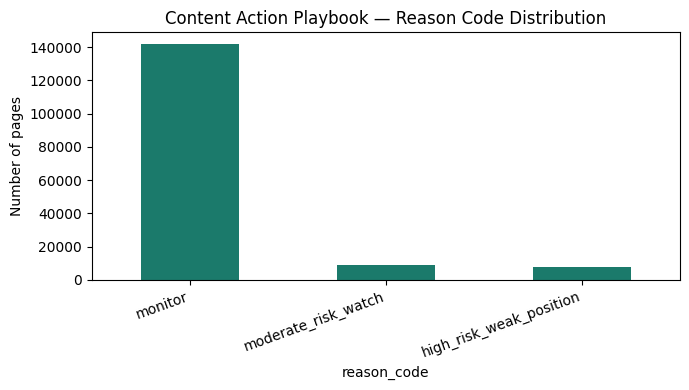

Figure saved -> work/figures/reason_code_distribution.png


In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ranked_queue["reason_code"].value_counts().plot(kind="bar", ax=ax, color="#1B7A6B")
ax.set_title("Content Action Playbook — Reason Code Distribution")
ax.set_ylabel("Number of pages")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()
print("Figure saved -> work/figures/reason_code_distribution.png")

In [27]:
"""
Exports for the paper:
- work/outputs/content_action_playbook_queue.csv -- the full ranked
  queue (158,549 rows), gitignored by design per the CI leak-guard;
  regenerates on every run.
- work/outputs/w07_playbook_metrics.json -- the committed "receipts":
  split design, base rate, Precision@50 for both the honest and naive
  splits, reason code counts, client coverage. These are the exact
  numbers next week's paper will cite.
- work/figures/reason_code_distribution.png -- committed figure showing
  how the ~158k scored pages split across reason codes, for reuse in
  the paper's recommendations section.
"""

'\nExports for the paper:\n- work/outputs/content_action_playbook_queue.csv -- the full ranked \n  queue (158,549 rows), gitignored by design per the CI leak-guard; \n  regenerates on every run.\n- work/outputs/w07_playbook_metrics.json -- the committed "receipts": \n  split design, base rate, Precision@50 for both the honest and naive \n  splits, reason code counts, client coverage. These are the exact \n  numbers next week\'s paper will cite.\n- work/figures/reason_code_distribution.png -- committed figure showing \n  how the ~158k scored pages split across reason codes, for reuse in \n  the paper\'s recommendations section.\n'

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.